# IMPUTACIÓN DE DATOS FALTANTES

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

# dataset sencillo
n = 100

df = pd.DataFrame({
    'edad': np.random.randint(20, 60, n),
    'ingreso': np.random.normal(3000, 800, n),
    'ciudad': np.random.choice(['Lima', 'Arequipa', 'Cusco'], n)
})

df.head()

,edad,ingreso,ciudad
0,58,2857.814303,Cusco
1,48,2671.693353,Lima
2,34,3943.773076,Arequipa
3,27,2281.433648,Arequipa
4,40,3667.836335,Cusco


# Caso MCAR (faltantes completamente aleatorios)

In [2]:
df_mcar = df.copy()

# 20% faltantes aleatorios
mask = np.random.rand(len(df_mcar)) < 0.2
df_mcar.loc[mask, 'ingreso'] = np.nan

df_mcar.head(10)

,edad,ingreso,ciudad
0,58,2857.814303,Cusco
1,48,2671.693353,Lima
2,34,3943.773076,Arequipa
3,27,NaN,Arequipa
4,40,NaN,Cusco
5,58,3237.249107,Arequipa
6,38,NaN,Lima
7,42,NaN,Cusco
8,30,3778.370827,Lima
9,30,NaN,Lima


 # Imputación con MEDIA

In [3]:
media = df_mcar['ingreso'].mean()

df_mcar['ingreso_imputado'] = df_mcar['ingreso'].fillna(media)

df_mcar.head(10)

,edad,ingreso,ciudad,ingreso_imputado
0,58,2857.814303,Cusco,2857.814303
1,48,2671.693353,Lima,2671.693353
2,34,3943.773076,Arequipa,3943.773076
3,27,NaN,Arequipa,3079.999453
4,40,NaN,Cusco,3079.999453
5,58,3237.249107,Arequipa,3237.249107
6,38,NaN,Lima,3079.999453
7,42,NaN,Cusco,3079.999453
8,30,3778.370827,Lima,3778.370827
9,30,NaN,Lima,3079.999453


In [4]:
mediana = df_mcar['ingreso'].median()

df_mcar['ingreso_imputado_mediana'] = df_mcar['ingreso'].fillna(mediana)

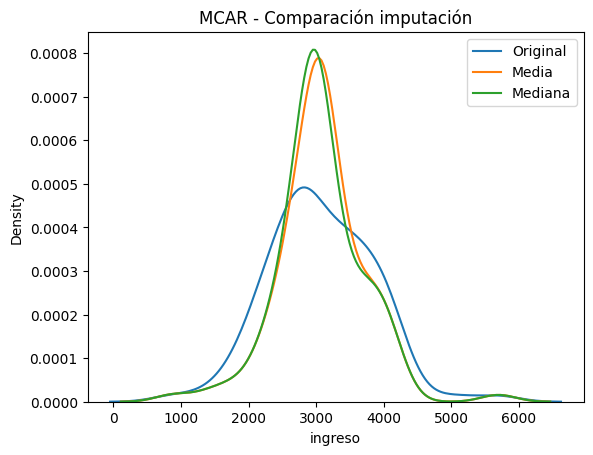

In [5]:
sns.kdeplot(df['ingreso'], label='Original')
sns.kdeplot(df_mcar['ingreso_imputado'], label='Media')
sns.kdeplot(df_mcar['ingreso_imputado_mediana'], label='Mediana')

plt.legend()
plt.title('MCAR - Comparación imputación')
plt.show()

En MCAR, como los datos faltan al azar, usar media o mediana funciona bien porque no introduce mucho sesgo.

# Caso MAR (depende de otra variable)

In [6]:
df_mar = df.copy()

# mayor probabilidad de faltante si edad < 30
prob = np.where(df_mar['edad'] < 30, 0.4, 0.1)
mask = np.random.rand(len(df_mar)) < prob

df_mar.loc[mask, 'ingreso'] = np.nan

df_mar.head(10)

,edad,ingreso,ciudad
0,58,2857.814303,Cusco
1,48,NaN,Lima
2,34,3943.773076,Arequipa
3,27,NaN,Arequipa
4,40,3667.836335,Cusco
5,58,3237.249107,Arequipa
6,38,2169.736099,Lima
7,42,2939.357004,Cusco
8,30,3778.370827,Lima
9,30,3636.476371,Lima


# ANALIZAMOS RELACIÓN ENTRE EDAD E INGRESO

In [7]:
df_mar.groupby(df_mar['ingreso'].isna())['edad'].mean()

,edad
ingreso,
False,40.130952
True,31.750000


# IMPUTACIÓN POR GRUPOS

In [8]:
df_mar['grupo_edad'] = pd.cut(df_mar['edad'], bins=[19,29,39,49,60])

df_mar['ingreso_imputado'] = df_mar['ingreso']

for grupo in df_mar['grupo_edad'].unique():
    mediana = df_mar.loc[
        (df_mar['grupo_edad'] == grupo) & (df_mar['ingreso'].notna()),
        'ingreso'
    ].median()

    df_mar.loc[
        (df_mar['grupo_edad'] == grupo) & (df_mar['ingreso'].isna()),
        'ingreso_imputado'
    ] = mediana

df_mar.head(10)

,edad,ingreso,ciudad,grupo_edad,ingreso_imputado
0,58,2857.814303,Cusco,"(49, 60]",2857.814303
1,48,NaN,Lima,"(39, 49]",3391.680972
2,34,3943.773076,Arequipa,"(29, 39]",3943.773076
3,27,NaN,Arequipa,"(19, 29]",2683.586839
4,40,3667.836335,Cusco,"(39, 49]",3667.836335
5,58,3237.249107,Arequipa,"(49, 60]",3237.249107
6,38,2169.736099,Lima,"(29, 39]",2169.736099
7,42,2939.357004,Cusco,"(39, 49]",2939.357004
8,30,3778.370827,Lima,"(29, 39]",3778.370827
9,30,3636.476371,Lima,"(29, 39]",3636.476371


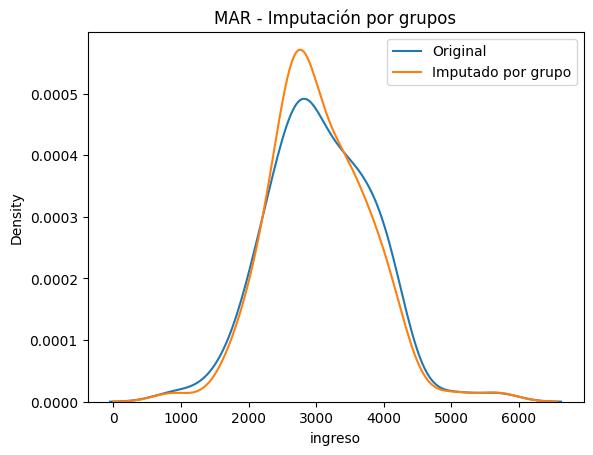

In [9]:
sns.kdeplot(df['ingreso'], label='Original')
sns.kdeplot(df_mar['ingreso_imputado'], label='Imputado por grupo')

plt.legend()
plt.title('MAR - Imputación por grupos')
plt.show()

# En MAR, los faltantes dependen de otra variable (edad), por eso:

👉 usar media global es mala idea
👉 mejor usar información adicional (grupos)

# Caso MNAR (depende del propio valor)

In [10]:
df_mnar = df.copy()

# si ingreso es alto, más probabilidad de faltar
threshold = df_mnar['ingreso'].quantile(0.75)

prob = np.where(df_mnar['ingreso'] > threshold, 0.5, 0.05)
mask = np.random.rand(len(df_mnar)) < prob

df_mnar.loc[mask, 'ingreso'] = np.nan

df_mnar.head(10)

,edad,ingreso,ciudad
0,58,2857.814303,Cusco
1,48,2671.693353,Lima
2,34,NaN,Arequipa
3,27,NaN,Arequipa
4,40,3667.836335,Cusco
5,58,3237.249107,Arequipa
6,38,2169.736099,Lima
7,42,2939.357004,Cusco
8,30,NaN,Lima
9,30,NaN,Lima


In [11]:
mediana = df_mnar['ingreso'].median()

df_mnar['ingreso_imputado'] = df_mnar['ingreso'].fillna(mediana)

In [12]:
df_mnar['faltante'] = df_mnar['ingreso'].isna().astype(int)

# Imputación con regla (percentil alto)

In [13]:
valor_alto = df_mnar['ingreso'].quantile(0.75)

df_mnar['ingreso_imputado_regla'] = df_mnar['ingreso'].fillna(valor_alto)

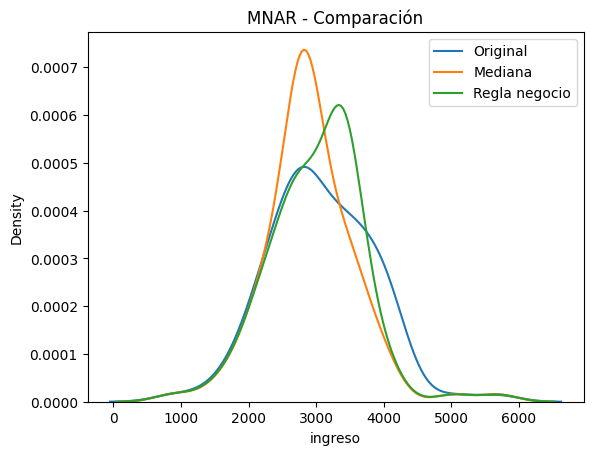

In [14]:
sns.kdeplot(df['ingreso'], label='Original')
sns.kdeplot(df_mnar['ingreso_imputado'], label='Mediana')
sns.kdeplot(df_mnar['ingreso_imputado_regla'], label='Regla negocio')

plt.legend()
plt.title('MNAR - Comparación')
plt.show()

## En MNAR:

* los datos faltantes tienen un patrón oculto
* imputar con media/mediana distorsiona la realidad

se recomienda:
* crear variable indicador
* usar reglas de negocio
* análisis más profundo